In [1]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

### 1. Import Library

Pada tahap ini, kita mengimpor semua library yang dibutuhkan untuk menjalankan proyek pengolahan citra dan klasifikasi. Berikut penjelasan dari masing-masing library
os: Untuk interaksi dengan sistem file (misalnya membaca direktori).

cv2 (OpenCV): Digunakan untuk membaca, memproses, dan manipulasi gambar.

matplotlib.pyplot: Untuk menampilkan visualisasi gambar dan grafik.

numpy: Digunakan untuk operasi numerik dan manipulasi array.

pandas: Untuk memproses dan menganalisis data dalam bentuk tabel.

sklearn.model_selection: Untuk melakukan pembagian data dan validasi model.

sklearn.metrics: Untuk mengukur performa model (akurasi, precision, recall, dll).

skimage.feature: Untuk ekstraksi fitur dari gambar seperti GLCM (gray-level co-occurrence matrix).

scipy.stats: Untuk fungsi statistik seperti entropi.

sklearn.ensemble, svm, dan neighbors: Kumpulan algoritma klasifikasi seperti Random Forest, SVM, dan KNN.

seaborn: Untuk visualisasi data yang lebih interaktif dan menarik.



### 2. Pembacaan Dataset

Data gambar dibaca dari folder `dataset/` yang berisi sub-folder per kelas. Setiap gambar disimpan ke dalam list `data`, label kelasnya ke `labels`, dan nama file ke `file_name`.

In [2]:
data = []
labels = []
file_name = []

IMG_SIZE = (128, 128)

for sub_folder in os.listdir("dataset"):
    sub_folder_files = os.listdir(os.path.join("dataset", sub_folder))
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join("dataset", sub_folder, filename)
        img = cv.imread(img_path)

        if img is None:
            continue

        data.append(img)
        labels.append(sub_folder)
        file_name.append(f"{sub_folder}_{i+1}.jpg")

print(f"Total data: {len(data)}")
print(f"Kelas: {sorted(set(labels))}")

Total data: 300
Kelas: ['anggrek', 'lili', 'matahari']


### 3. Pereprocessing

### 3.1. Fungsi-Fungsi Preprocessing

Tiga fungsi preprocessing didefinisikan untuk menyiapkan citra sebelum ekstraksi fitur:

- **`resize_grayscale`** — Mengubah ukuran gambar ke `128×128` piksel dan mengkonversi dari BGR ke grayscale.
- **`median_filter`** — Menerapkan median blur dengan kernel `5×5` untuk mengurangi noise pada gambar.
- **`histogram_equalization_grayscale`** — Melakukan ekualisasi histogram untuk meningkatkan kontras gambar grayscale.

In [3]:
TARGET_SIZE = (128, 128)

def resize_grayscale(image, target_size=TARGET_SIZE):
    resized = cv.resize(image, target_size)
    if len(resized.shape) == 3:
        gray = cv.cvtColor(resized, cv.COLOR_BGR2GRAY)
    else:
        gray = resized
    return gray.astype(np.uint8)


def median_filter(image_input, kernel_size=5):
    if isinstance(image_input, str):
        img = cv.imread(image_input)
    else:
        img = image_input.copy()

    median_result = cv.medianBlur(img, kernel_size)
    return median_result


def histogram_equalization_grayscale(image_input):
    if isinstance(image_input, str):
        img = cv.imread(image_input, cv.IMREAD_GRAYSCALE)
    else:
        img = image_input.copy()

    equalized_result = cv.equalizeHist(img)

    return equalized_result

### 3.2. Pipeline Preprocessing

Ketiga fungsi digabungkan dalam satu pipeline `prepro()` dengan urutan:

**Resize + Grayscale → Median Filter → Histogram Equalization**

In [4]:
def prepro(image):
    # Resize + Grayscale
    img = resize_grayscale(image)
    # median_filter
    img = median_filter(img)
    # histogram_equalization_grayscale
    img = histogram_equalization_grayscale(img)
    return img

### 3.3. Penerapan Preprocessing dan Visualisasi

Preprocessing diterapkan ke seluruh dataset, lalu hasil citra ditampilkan per kelas dalam grid `7×10`.

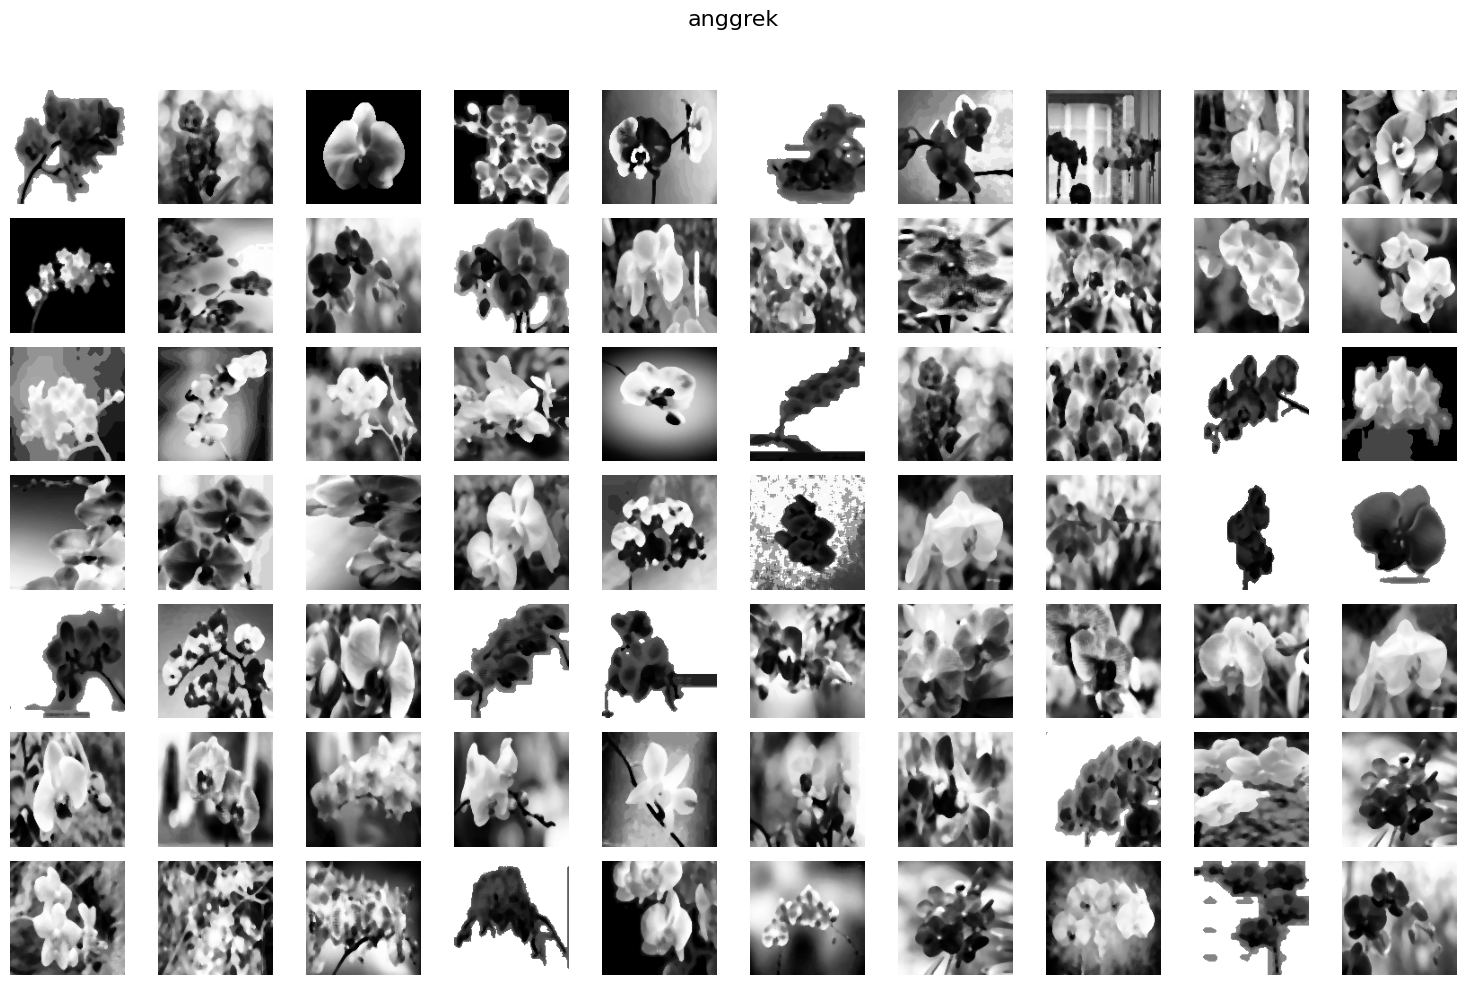

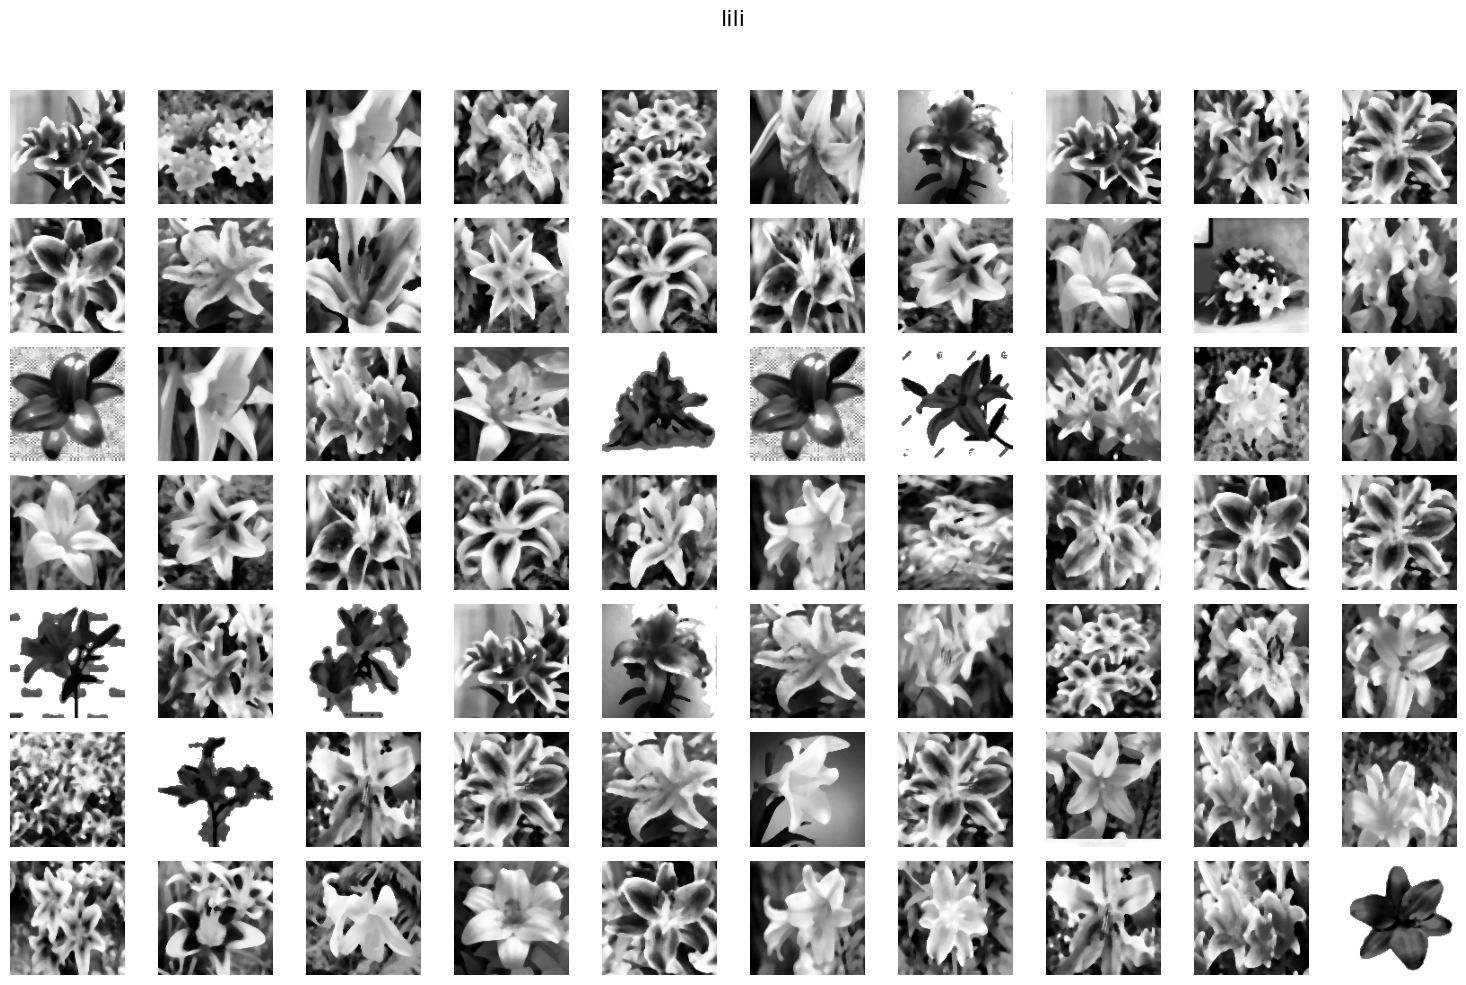

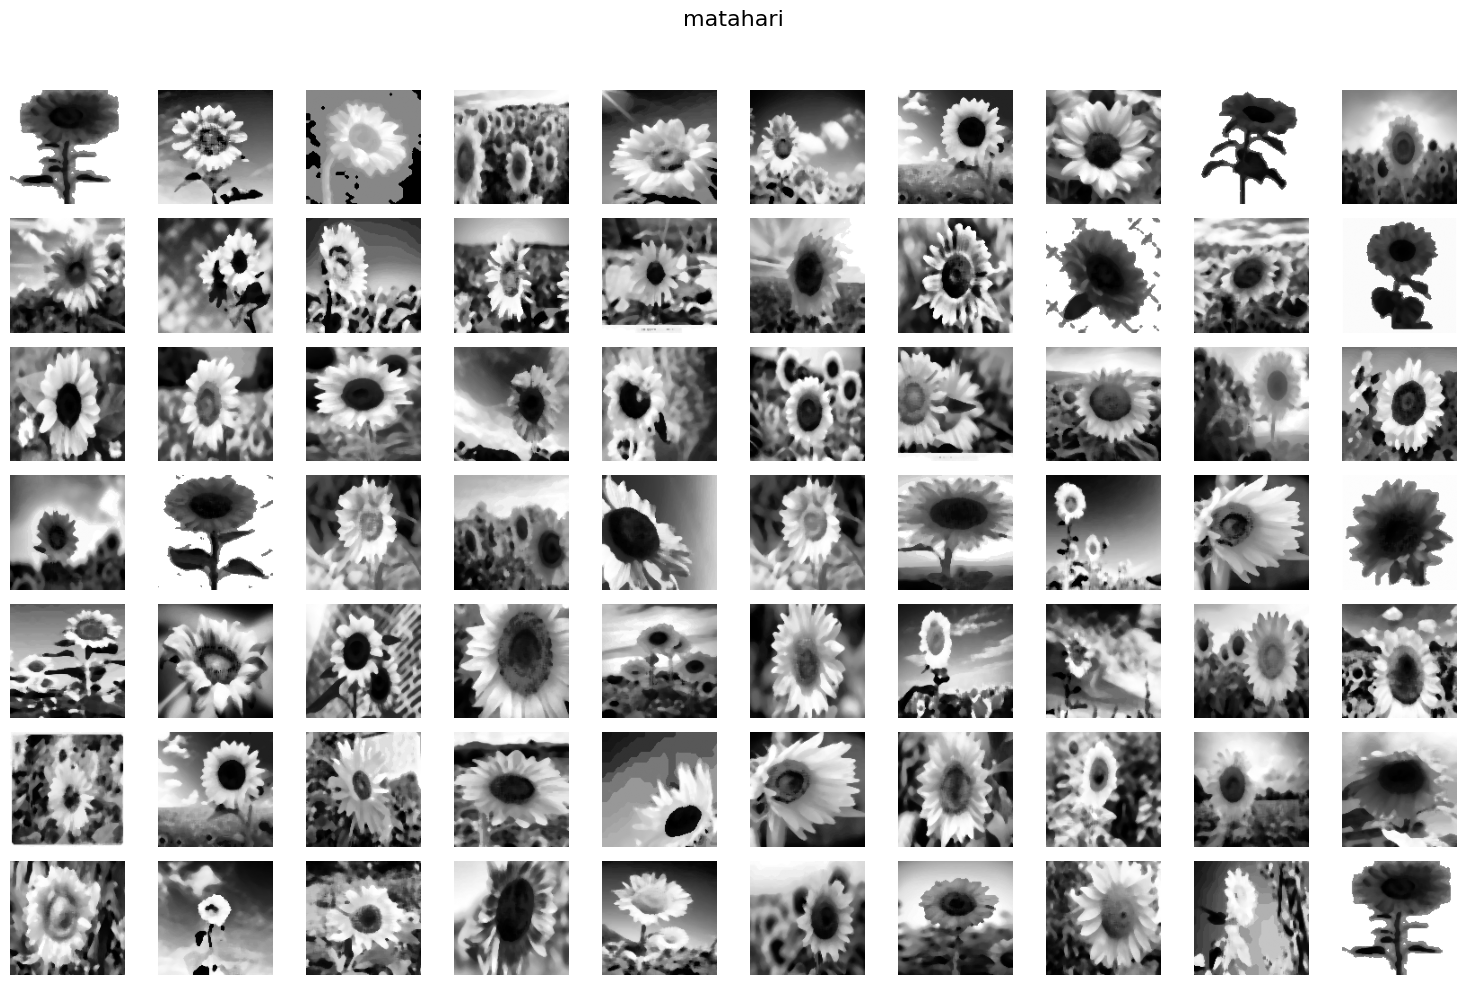

In [5]:
def percobaan2(img):
    hasil = prepro(img)
    return hasil

dataPreprocessed = [percobaan2(img) for img in data]

unique_labels = sorted(set(labels))

for label in unique_labels:
    idxs = [j for j, l in enumerate(labels) if l == label]

    fig, axs = plt.subplots(7, 10, figsize=(15, 10)) 
    fig.suptitle(f'{label}', fontsize=16)

    for k in range(min(70, len(idxs))):
        
        row = k // 10  
        col = k % 10   
        
        ax = axs[row][col]

        ax.imshow(dataPreprocessed[idxs[k]], cmap='gray')
        ax.axis('off')
        
    for k in range(len(idxs), 70):
        row = k // 10
        col = k % 10
        axs[row][col].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

## 4. Ekstraksi Fitur GLCM

### 4.1. Fungsi Pembentukan Matriks GLCM

GLCM (Gray-Level Co-occurrence Matrix) dihitung untuk empat arah sudut: **0°, 45°, 90°, dan 135°**.

In [6]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

### 4.2. Fungsi Ekstraksi Properti GLCM

Dari setiap matriks GLCM, diekstrak tujuh properti tekstur:

| Properti | Deskripsi |
|---|---|
| **Contrast** | Mengukur perbedaan intensitas antara piksel yang berdekatan |
| **Dissimilarity** | Mengukur ketidakmiripan distribusi intensitas |
| **Homogeneity** | Mengukur kedekatan distribusi elemen GLCM terhadap diagonal |
| **Entropy** | Mengukur ketidakteraturan atau kerumitan tekstur |
| **ASM** | Angular Second Moment — mengukur keseragaman tekstur |
| **Energy** | Akar dari ASM, menggambarkan keseragaman citra |
| **Correlation** | Mengukur ketergantungan linear intensitas piksel |

In [7]:
def correlation_feat(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

### 4.3. Perhitungan GLCM untuk Seluruh Dataset

Matriks GLCM dihitung untuk keempat sudut pada setiap citra, kemudian setiap properti tekstur diekstrak.

> **Total fitur yang dihasilkan: 7 properti × 4 sudut (0°, 45°, 90°, 135°) = 28 fitur per citra.**

In [8]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []

for i in range(len(dataPreprocessed)):
    D0   = glcm(dataPreprocessed[i], 0)
    D45  = glcm(dataPreprocessed[i], 45)
    D90  = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

Kontras0, Kontras45, Kontras90, Kontras135         = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135         = [], [], [], []
ASM0, ASM45, ASM90, ASM135                         = [], [], [], []
energy0, energy45, energy90, energy135             = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

    correlation0.append(correlation_feat(Derajat0[i]))
    correlation45.append(correlation_feat(Derajat45[i]))
    correlation90.append(correlation_feat(Derajat90[i]))
    correlation135.append(correlation_feat(Derajat135[i]))

print(f"Ekstraksi fitur selesai untuk {len(dataPreprocessed)} citra.")

Ekstraksi fitur selesai untuk 300 citra.


## 5. Penyimpanan dan Pembacaan Tabel Fitur

Seluruh fitur hasil ekstraksi disusun ke dalam DataFrame dan disimpan sebagai file CSV `hasil_ekstraksi_pros2.csv`.

In [9]:
dataTable = {
    'Filename': file_name, 'Label': labels,
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
}
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_pros2.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_pros2.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,anggrek_1.jpg,anggrek,441.327141,672.916486,349.148991,576.233864,0.612232,0.568294,0.634353,0.563526,...,0.177085,0.167790,0.418599,0.408987,0.420814,0.409621,0.975782,0.963031,0.980841,0.968343
1,anggrek_2.jpg,anggrek,191.433440,286.220162,120.362328,250.659185,0.301281,0.243784,0.335861,0.255976,...,0.000991,0.000676,0.029188,0.025677,0.031487,0.025995,0.982522,0.973739,0.988960,0.977002
2,anggrek_3.jpg,anggrek,448.285556,638.723541,336.968381,514.467853,0.718791,0.695780,0.725377,0.703022,...,0.367573,0.360284,0.605166,0.600284,0.606278,0.600237,0.962872,0.947342,0.972092,0.957586
3,anggrek_4.jpg,anggrek,539.835753,830.713125,502.149114,902.878046,0.500486,0.451145,0.515331,0.448595,...,0.101420,0.095441,0.317638,0.310304,0.318465,0.308935,0.962216,0.941851,0.964884,0.936797
4,anggrek_5.jpg,anggrek,634.718565,818.989274,322.479700,759.498667,0.595889,0.588951,0.721937,0.550706,...,0.013804,0.009613,0.102693,0.103130,0.117490,0.098044,0.941595,0.924941,0.970521,0.930394
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,matahari_96.jpg,matahari,486.688607,769.540455,597.259227,908.739785,0.750218,0.726482,0.769309,0.706630,...,0.350571,0.340632,0.593630,0.585765,0.592090,0.583637,0.975571,0.961495,0.970036,0.954529
296,matahari_97.jpg,matahari,306.140317,430.303925,195.773499,443.726207,0.320348,0.255617,0.375908,0.266032,...,0.001148,0.000724,0.030380,0.026494,0.033884,0.026910,0.971851,0.960417,0.981928,0.959182
297,matahari_98.jpg,matahari,413.596334,571.041540,203.190453,522.288425,0.322916,0.252052,0.355964,0.264245,...,0.001109,0.000739,0.030609,0.026096,0.033302,0.027184,0.961871,0.947531,0.981312,0.952014
298,matahari_99.jpg,matahari,264.167077,445.593465,183.141056,344.073036,0.346215,0.273934,0.358277,0.277006,...,0.002034,0.001617,0.044794,0.039982,0.045095,0.040212,0.975870,0.959394,0.983333,0.968645


## 6. Seleksi Fitur Berdasarkan Korelasi

### 6.1. Penghapusan Fitur Redundan

Fitur yang memiliki korelasi **≥ 0.95** satu sama lain dianggap redundan dan salah satunya dihapus untuk mengurangi dimensi data.

### 6.2. Visualisasi Heatmap Korelasi

Heatmap korelasi ditampilkan untuk melihat hubungan antar fitur yang telah diseleksi.

Fitur sebelum seleksi : 28
Fitur setelah seleksi : 11
Fitur terpilih        : ['Contrast0', 'Contrast45', 'Contrast90', 'Homogeneity0', 'Dissimilarity0', 'Dissimilarity45', 'Dissimilarity90', 'ASM0', 'Correlation0', 'Correlation45', 'Correlation90']


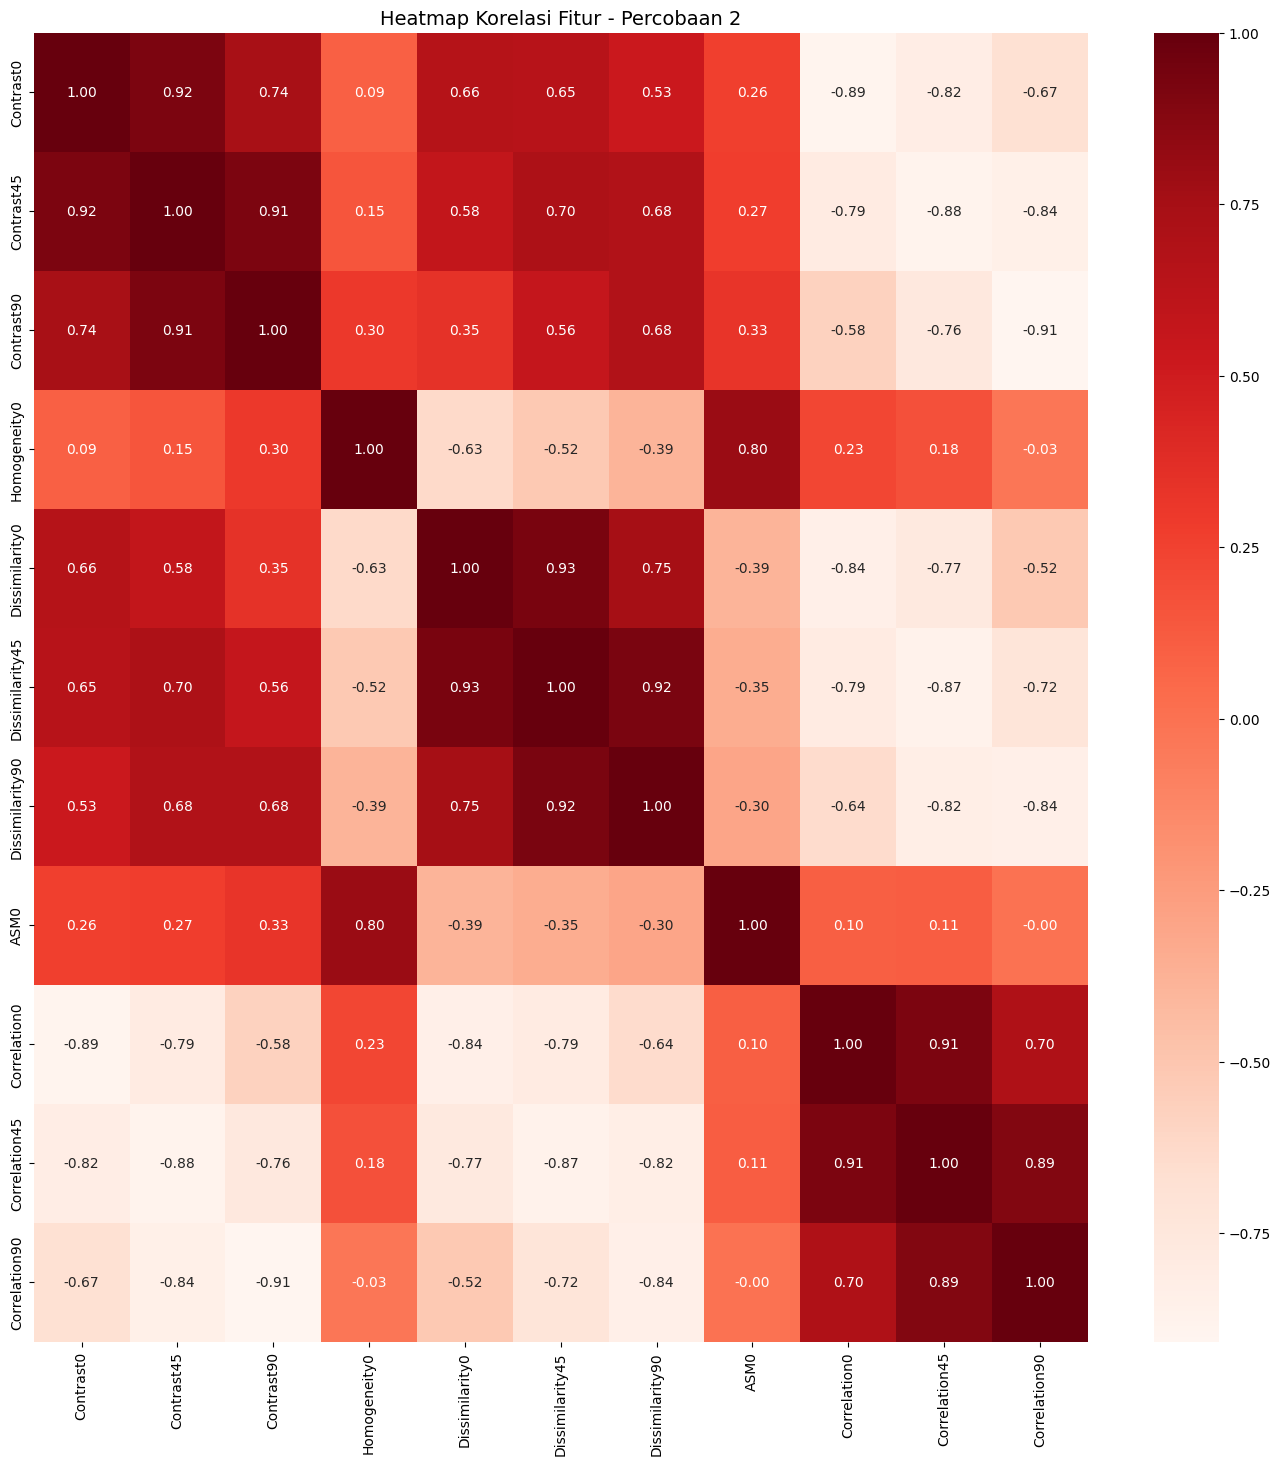

In [10]:
corr_matrix = hasilEkstrak.drop(columns=['Label','Filename']).corr()

threshold = 0.95
columns = np.full((corr_matrix.shape[0],), True, dtype=bool)
for i in range(corr_matrix.shape[0]):
    for j in range(i+1, corr_matrix.shape[0]):
        if abs(corr_matrix.iloc[i,j]) >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f"Fitur sebelum seleksi : 28")
print(f"Fitur setelah seleksi : {len(select)}")
print(f"Fitur terpilih        : {list(select)}")

plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Reds', fmt=".2f")
plt.title('Heatmap Korelasi Fitur - Percobaan 2', fontsize=14)
plt.show()

## 7. Pembagian Data (Train/Test Split)

Dataset dibagi menjadi data latih dan data uji dengan rasio **80:20** menggunakan `random_state=42` agar hasil dapat direproduksi.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(240, 11)
(60, 11)


## 8. Normalisasi Data (Standardisasi)

Data dinormalisasi menggunakan **Z-score standardization**. Parameter (mean dan std) dihitung dari data latih, lalu diterapkan ke data latih dan data uji untuk menghindari kebocoran data (*data leakage*).

In [12]:
mean_train = X_train.mean()
std_train  = X_train.std()

X_test  = (X_test  - mean_train) / std_train
X_train = (X_train - mean_train) / std_train

## 9. Pelatihan dan Evaluasi Model

### 9.1. Definisi Fungsi Evaluasi dan Model

Fungsi `generateClassificationReport` digunakan untuk menampilkan classification report, confusion matrix, dan akurasi. Tiga model didefinisikan:
- **Random Forest** — ensemble 5 decision tree
- **SVM** — kernel RBF
- **KNN** — k = 5 tetangga terdekat

In [13]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf  = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

### 9.2. Random Forest

In [14]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport(y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

     anggrek       0.92      0.97      0.94        78
        lili       0.96      0.95      0.96        84
    matahari       0.95      0.90      0.92        78

    accuracy                           0.94       240
   macro avg       0.94      0.94      0.94       240
weighted avg       0.94      0.94      0.94       240

[[76  0  2]
 [ 2 80  2]
 [ 5  3 70]]
Accuracy: 0.9416666666666667

------Testing Set------
              precision    recall  f1-score   support

     anggrek       0.59      0.77      0.67        22
        lili       0.67      0.62      0.65        16
    matahari       0.81      0.59      0.68        22

    accuracy                           0.67        60
   macro avg       0.69      0.66      0.67        60
weighted avg       0.69      0.67      0.67        60

[[17  3  2]
 [ 5 10  1]
 [ 7  2 13]]
Accuracy: 0.6666666666666666


### 9.3. Support Vector Machine (SVM)

In [15]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport(y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

     anggrek       0.53      0.62      0.57        78
        lili       0.63      0.56      0.59        84
    matahari       0.61      0.58      0.59        78

    accuracy                           0.58       240
   macro avg       0.59      0.58      0.58       240
weighted avg       0.59      0.58      0.58       240

[[48 15 15]
 [23 47 14]
 [20 13 45]]
Accuracy: 0.5833333333333334

------Testing Set------
              precision    recall  f1-score   support

     anggrek       0.54      0.59      0.57        22
        lili       0.36      0.50      0.42        16
    matahari       0.64      0.41      0.50        22

    accuracy                           0.50        60
   macro avg       0.52      0.50      0.50        60
weighted avg       0.53      0.50      0.50        60

[[13  7  2]
 [ 5  8  3]
 [ 6  7  9]]
Accuracy: 0.5


### 9.4. K-Nearest Neighbors (KNN)

In [16]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport(y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

     anggrek       0.70      0.73      0.71        78
        lili       0.65      0.85      0.74        84
    matahari       0.71      0.45      0.55        78

    accuracy                           0.68       240
   macro avg       0.69      0.67      0.67       240
weighted avg       0.69      0.68      0.67       240

[[57 12  9]
 [ 8 71  5]
 [17 26 35]]
Accuracy: 0.6791666666666667

------Testing Set------
              precision    recall  f1-score   support

     anggrek       0.46      0.55      0.50        22
        lili       0.39      0.69      0.50        16
    matahari       0.67      0.18      0.29        22

    accuracy                           0.45        60
   macro avg       0.51      0.47      0.43        60
weighted avg       0.52      0.45      0.42        60

[[12  8  2]
 [ 5 11  0]
 [ 9  9  4]]
Accuracy: 0.45


## 10. Visualisasi Confusion Matrix

Confusion matrix ditampilkan untuk setiap model pada data uji, dengan label kelas: **Anggrek, Lili, Matahari**.

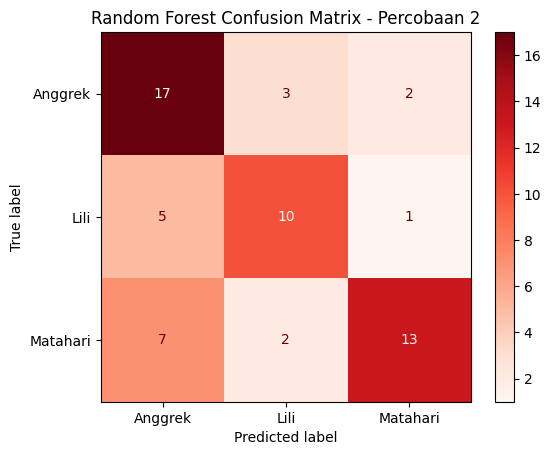

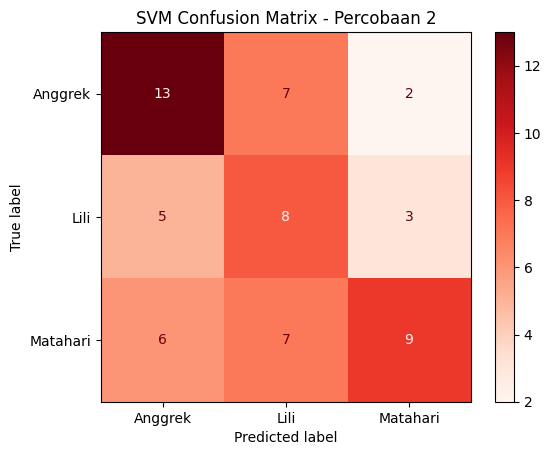

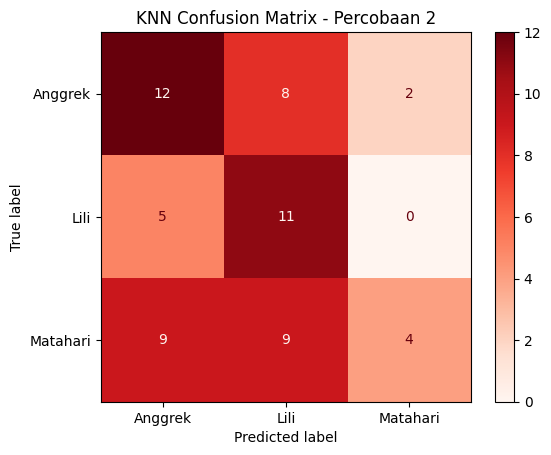

In [17]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Anggrek', 'Lili', 'Matahari']
    )

    disp.plot(cmap=plt.cm.Reds, values_format='d')
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(
    y_test,
    rf.predict(X_test),
    "Random Forest Confusion Matrix - Percobaan 2"
)

# Plot confusion matrix for SVM
plot_confusion_matrix(
    y_test,
    svm.predict(X_test),
    "SVM Confusion Matrix - Percobaan 2"
)

# Plot confusion matrix for KNN
plot_confusion_matrix(
    y_test,
    knn.predict(X_test),
    "KNN Confusion Matrix - Percobaan 2"
)

## 11. Perbandingan Hasil Klasifikasi

Semua metrik evaluasi dari ketiga model dikompilasi ke dalam tabel dan disimpan sebagai file `hasil_klasifikasi_pros2.csv`.

Metrik yang dibandingkan:
- **Accuracy Train** — akurasi pada data latih
- **Accuracy Test** — akurasi pada data uji
- **Precision** — ketepatan prediksi positif (weighted average)
- **Recall** — kemampuan mendeteksi kelas yang benar (weighted average)
- **F1-Score** — rata-rata harmonik precision dan recall (weighted average)

In [18]:
# Simpan hasil perbandingan model
hasil_klasifikasi = {
    'Model'    : ['Random Forest', 'SVM', 'KNN'],
    'Accuracy_Train': [
        accuracy_score(y_train, rf.predict(X_train)),
        accuracy_score(y_train, svm.predict(X_train)),
        accuracy_score(y_train, knn.predict(X_train)),
    ],
    'Accuracy_Test': [
        accuracy_score(y_test, rf.predict(X_test)),
        accuracy_score(y_test, svm.predict(X_test)),
        accuracy_score(y_test, knn.predict(X_test)),
    ],
    'Precision': [
        precision_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        precision_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        precision_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'Recall': [
        recall_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        recall_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        recall_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'F1_Score': [
        f1_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        f1_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        f1_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
}
df_hasil = pd.DataFrame(hasil_klasifikasi)
df_hasil.to_csv('hasil_klasifikasi_pros2.csv', index=False)
print("✅ File hasil_klasifikasi_pros2.csv berhasil disimpan!")
df_hasil

✅ File hasil_klasifikasi_pros2.csv berhasil disimpan!


,Model,Accuracy_Train,Accuracy_Test,Precision,Recall,F1_Score
0,Random Forest,0.941667,0.666667,0.690637,0.666667,0.667365
1,SVM,0.583333,0.500000,0.531295,0.500000,0.502860
2,KNN,0.679167,0.450000,0.518437,0.450000,0.421429


---

## Ringkasan Alur Percobaan 2

```
Dataset
   ↓
Preprocessing
   ├── Resize + Grayscale (128×128)
   ├── Median Filter (kernel 5×5)
   └── Histogram Equalization
   ↓
Ekstraksi Fitur GLCM
   └── 7 properti × 4 sudut (0°, 45°, 90°, 135°) = 28 fitur
   ↓
Seleksi Fitur (threshold korelasi ≥ 0.95)
   ↓
Train/Test Split (80:20)
   ↓
Normalisasi Z-Score
   ↓
Pelatihan & Evaluasi Model
   ├── Random Forest
   ├── SVM (RBF Kernel)
   └── KNN (k=5)
   ↓
Confusion Matrix & Tabel Perbandingan
```